In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import regionmask
from matplotlib.gridspec import GridSpec
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import matplotlib.cm as mpl_cm
from scipy import stats

In [2]:
# === Processing functions ===
def adjust_longitude(dataset: xr.Dataset) -> xr.Dataset:
        """Swaps longitude coordinates from range (0, 360) to (-180, 180)
        Args:
            dataset (xr.Dataset): xarray Dataset
        Returns:
            xr.Dataset: xarray Dataset with swapped longitude dimensions
        """
        lon_name = "lon"  # whatever name is in the data

        # Adjust lon values to make sure they are within (-180, 180)
        dataset["_longitude_adjusted"] = xr.where(
            dataset[lon_name] > 180, dataset[lon_name] - 360, dataset[lon_name])
        dataset = (
            dataset.swap_dims({lon_name: "_longitude_adjusted"})
            .sel(**{"_longitude_adjusted": sorted(dataset._longitude_adjusted)})
            .drop_vars(lon_name)
        )

        dataset = dataset.rename({"_longitude_adjusted": lon_name})
        return dataset


# === Figure sizing ===
def autosize_figure(nrows, ncolumns, scale_factor=1, xscale_factor=1, yscale_factor=1):
    xwidth = (ncolumns+0.67) * 5.0 * scale_factor * xscale_factor
    ylength = (nrows+0.67) * 3.6 * scale_factor * yscale_factor
    return (xwidth, ylength)


# === Removing ocean ===
def land_filter(da):
    # Load in land fraction dataset
    land_110 = regionmask.defined_regions.natural_earth_v4_1_0.land_110
    da = da.where(land_110.mask_3D(da).squeeze())
    return da

In [3]:
# === Concatenate ensemble members ===
def merge_ensembles(VAR_DIR, VAR, scenario, dates, start, end, time_mean=False, land_mask=False):
    """ land_filter=True allows for the land filter function to remove the ocean """
    ens = []

    for ens_num in range(1, 11):
        da = xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_{scenario}_{ens_num:02d}_{dates}.nc").sel(year=slice(start, end))
        if time_mean is True:
            da = da.mean("year")
        ens.append(da)

    new_da = xr.concat(ens, dim=xr.DataArray(np.arange(1, len(ens)+1), dims="ensemble", name="ensemble"))

    if land_mask is True:
        print("Filtering ocean")
        new_da = land_filter(new_da)

    return new_da

In [4]:
# === Path config ===
OSDMA8_DIR = "/glade/work/awells/air_quality/CESM/ozone/OSDMA8_BC/"

# === Main loop ===
arise_o3 = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "ARISE", "2035-2069", "2050", "2069", time_mean=True, land_mask=True)
ssp245_o3_late = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "SSP245", "2020-2069", "2050", "2069", time_mean=True, land_mask=True)

Filtering ocean
Filtering ocean


In [26]:
# Calculate statistical signficance

In [5]:
# === Stats functions ===
def process_da_for_stats(da, start_year, end_year):
    da_r = da.sel(time=slice(start_year, end_year)).sel(ensemble=1)
    for i in range(2, len(da.ensemble)+1):
        da_ens = da.sel(time=slice(start_year, end_year)).sel(ensemble=i)
        da_r = xr.concat((da_r, da_ens), dim="time")
    return da_r


def stat_sig(da1, da2):
    # For latitude, longitude plots
    stat, pval = stats.ttest_ind(da1, da2)
    pval_da = xr.DataArray(data=pval,
                           dims=["lat", "lon"],
                           coords=dict(lon=(["lon"], da1.lon.values),
                                       lat=(["lat"], da1.lat.values)))
    return pval_da

In [6]:
pval = stat_sig(arise_o3, ssp245_o3_late)

KeyboardInterrupt: 

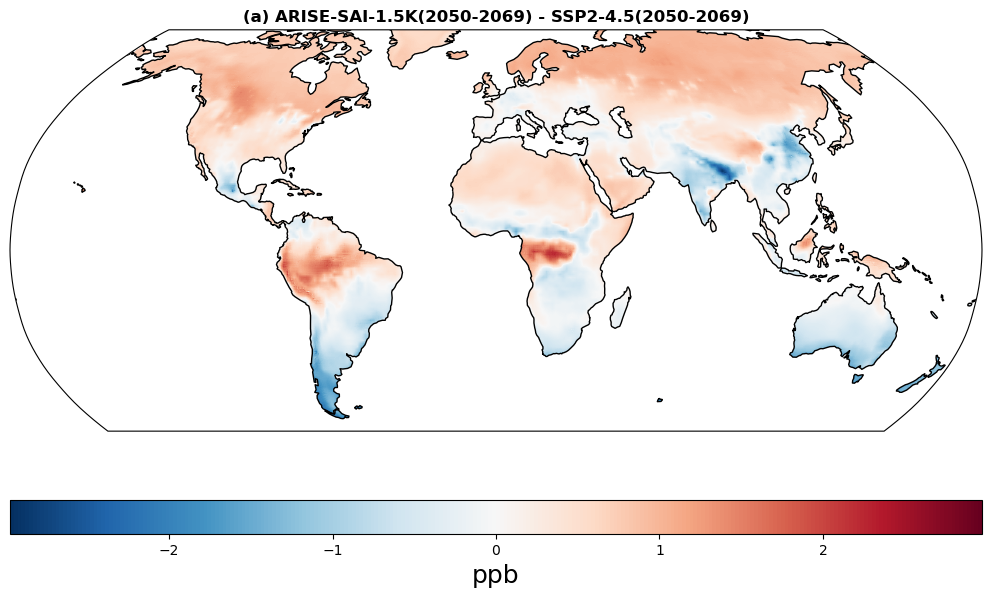

In [8]:
fig = plt.figure(figsize=autosize_figure(1, 1, scale_factor=1.2))
gs = GridSpec(2, 1, height_ratios=[20, 1]) # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

arise = arise_o3.mean("ensemble")
ssp245_late = ssp245_o3_late.mean("ensemble")

# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = (arise - ssp245_late).plot(transform=crs, add_colorbar=False, subplot_kws={'projection': projection})
# pval.where(pval > 0.05).plot.contourf(transform=crs, colors='none', levels=[0, 1], hatches=['...'], add_colorbar=False)
ax.coastlines()
plt.title('(a) ARISE-SAI-1.5K(2050-2069) - SSP2-4.5(2050-2069)', fontweight='bold')

# First colorbar
cax = fig.add_subplot(gs[1, 0])
col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
col_bar.set_label('ppb', fontsize=18)

plt.tight_layout()


In [31]:
# === Path config ===
OSDMA8_DIR = "/glade/work/awells/air_quality/CESM/ozone/OSDMA8_BC/"

# === Main loop ===
arise_30s = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "ARISE", "2035-2069", "2035", "2039", time_mean=True, land_mask=True)
ssp245_30s = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "SSP245", "2020-2069", "2035", "2039", time_mean=True, land_mask=True)

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 04
Processing ensemble number 05
Processing ensemble number 06
Processing ensemble number 07
Processing ensemble number 08
Processing ensemble number 09
Processing ensemble number 10
Filtering ocean
Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 04
Processing ensemble number 05
Processing ensemble number 06
Processing ensemble number 07
Processing ensemble number 08
Processing ensemble number 09
Processing ensemble number 10
Filtering ocean


In [32]:
arise_40s = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "ARISE", "2035-2069", "2040", "2049", time_mean=True, land_mask=True)
ssp245_40s = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "SSP245", "2020-2069", "2040", "2049", time_mean=True, land_mask=True)

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 04
Processing ensemble number 05
Processing ensemble number 06
Processing ensemble number 07
Processing ensemble number 08
Processing ensemble number 09
Processing ensemble number 10
Filtering ocean
Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 04
Processing ensemble number 05
Processing ensemble number 06
Processing ensemble number 07
Processing ensemble number 08
Processing ensemble number 09
Processing ensemble number 10
Filtering ocean


In [33]:
arise_50s = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "ARISE", "2035-2069", "2050", "2059", time_mean=True, land_mask=True)
ssp245_50s = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "SSP245", "2020-2069", "2050", "2059", time_mean=True, land_mask=True)

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 04
Processing ensemble number 05
Processing ensemble number 06
Processing ensemble number 07
Processing ensemble number 08
Processing ensemble number 09
Processing ensemble number 10
Filtering ocean
Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 04
Processing ensemble number 05
Processing ensemble number 06
Processing ensemble number 07
Processing ensemble number 08
Processing ensemble number 09
Processing ensemble number 10
Filtering ocean


In [34]:
arise_60s = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "ARISE", "2035-2069", "2060", "2069", time_mean=True, land_mask=True)
ssp245_60s = merge_ensembles(OSDMA8_DIR, "OSDMA8_BC", "SSP245", "2020-2069", "2060", "2069", time_mean=True, land_mask=True)

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 04
Processing ensemble number 05
Processing ensemble number 06
Processing ensemble number 07
Processing ensemble number 08
Processing ensemble number 09
Processing ensemble number 10
Filtering ocean
Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 04
Processing ensemble number 05
Processing ensemble number 06
Processing ensemble number 07
Processing ensemble number 08
Processing ensemble number 09
Processing ensemble number 10
Filtering ocean


In [35]:
diff_30s = (arise_30s - ssp245_30s).mean("ensemble")
diff_40s = (arise_40s - ssp245_40s).mean("ensemble")
diff_50s = (arise_50s - ssp245_50s).mean("ensemble")
diff_60s = (arise_60s - ssp245_60s).mean("ensemble")

In [39]:
def alt_process_da_for_stats(da):
    da_r = da.sel(ensemble=1)
    for i in range(2, len(da.ensemble)+1):
        da_ens = da.sel(ensemble=i)
        da_r = xr.concat((da_r, da_ens), dim="time")
    return da_r

In [42]:
arise_30s_proc = alt_process_da_for_stats(arise_30s)
ssp245_30s_proc = alt_process_da_for_stats(ssp245_30s)

In [43]:
stat_sig(arise_30s_proc, ssp245_30s_proc)

KeyboardInterrupt: 

In [36]:
pval_30s = stat_sig(arise_30s, ssp245_30s)
pval_40s = stat_sig(arise_40s, ssp245_40s)
pval_50s = stat_sig(arise_50s, ssp245_50s)
pval_60s = stat_sig(arise_60s, ssp245_60s)

KeyboardInterrupt: 

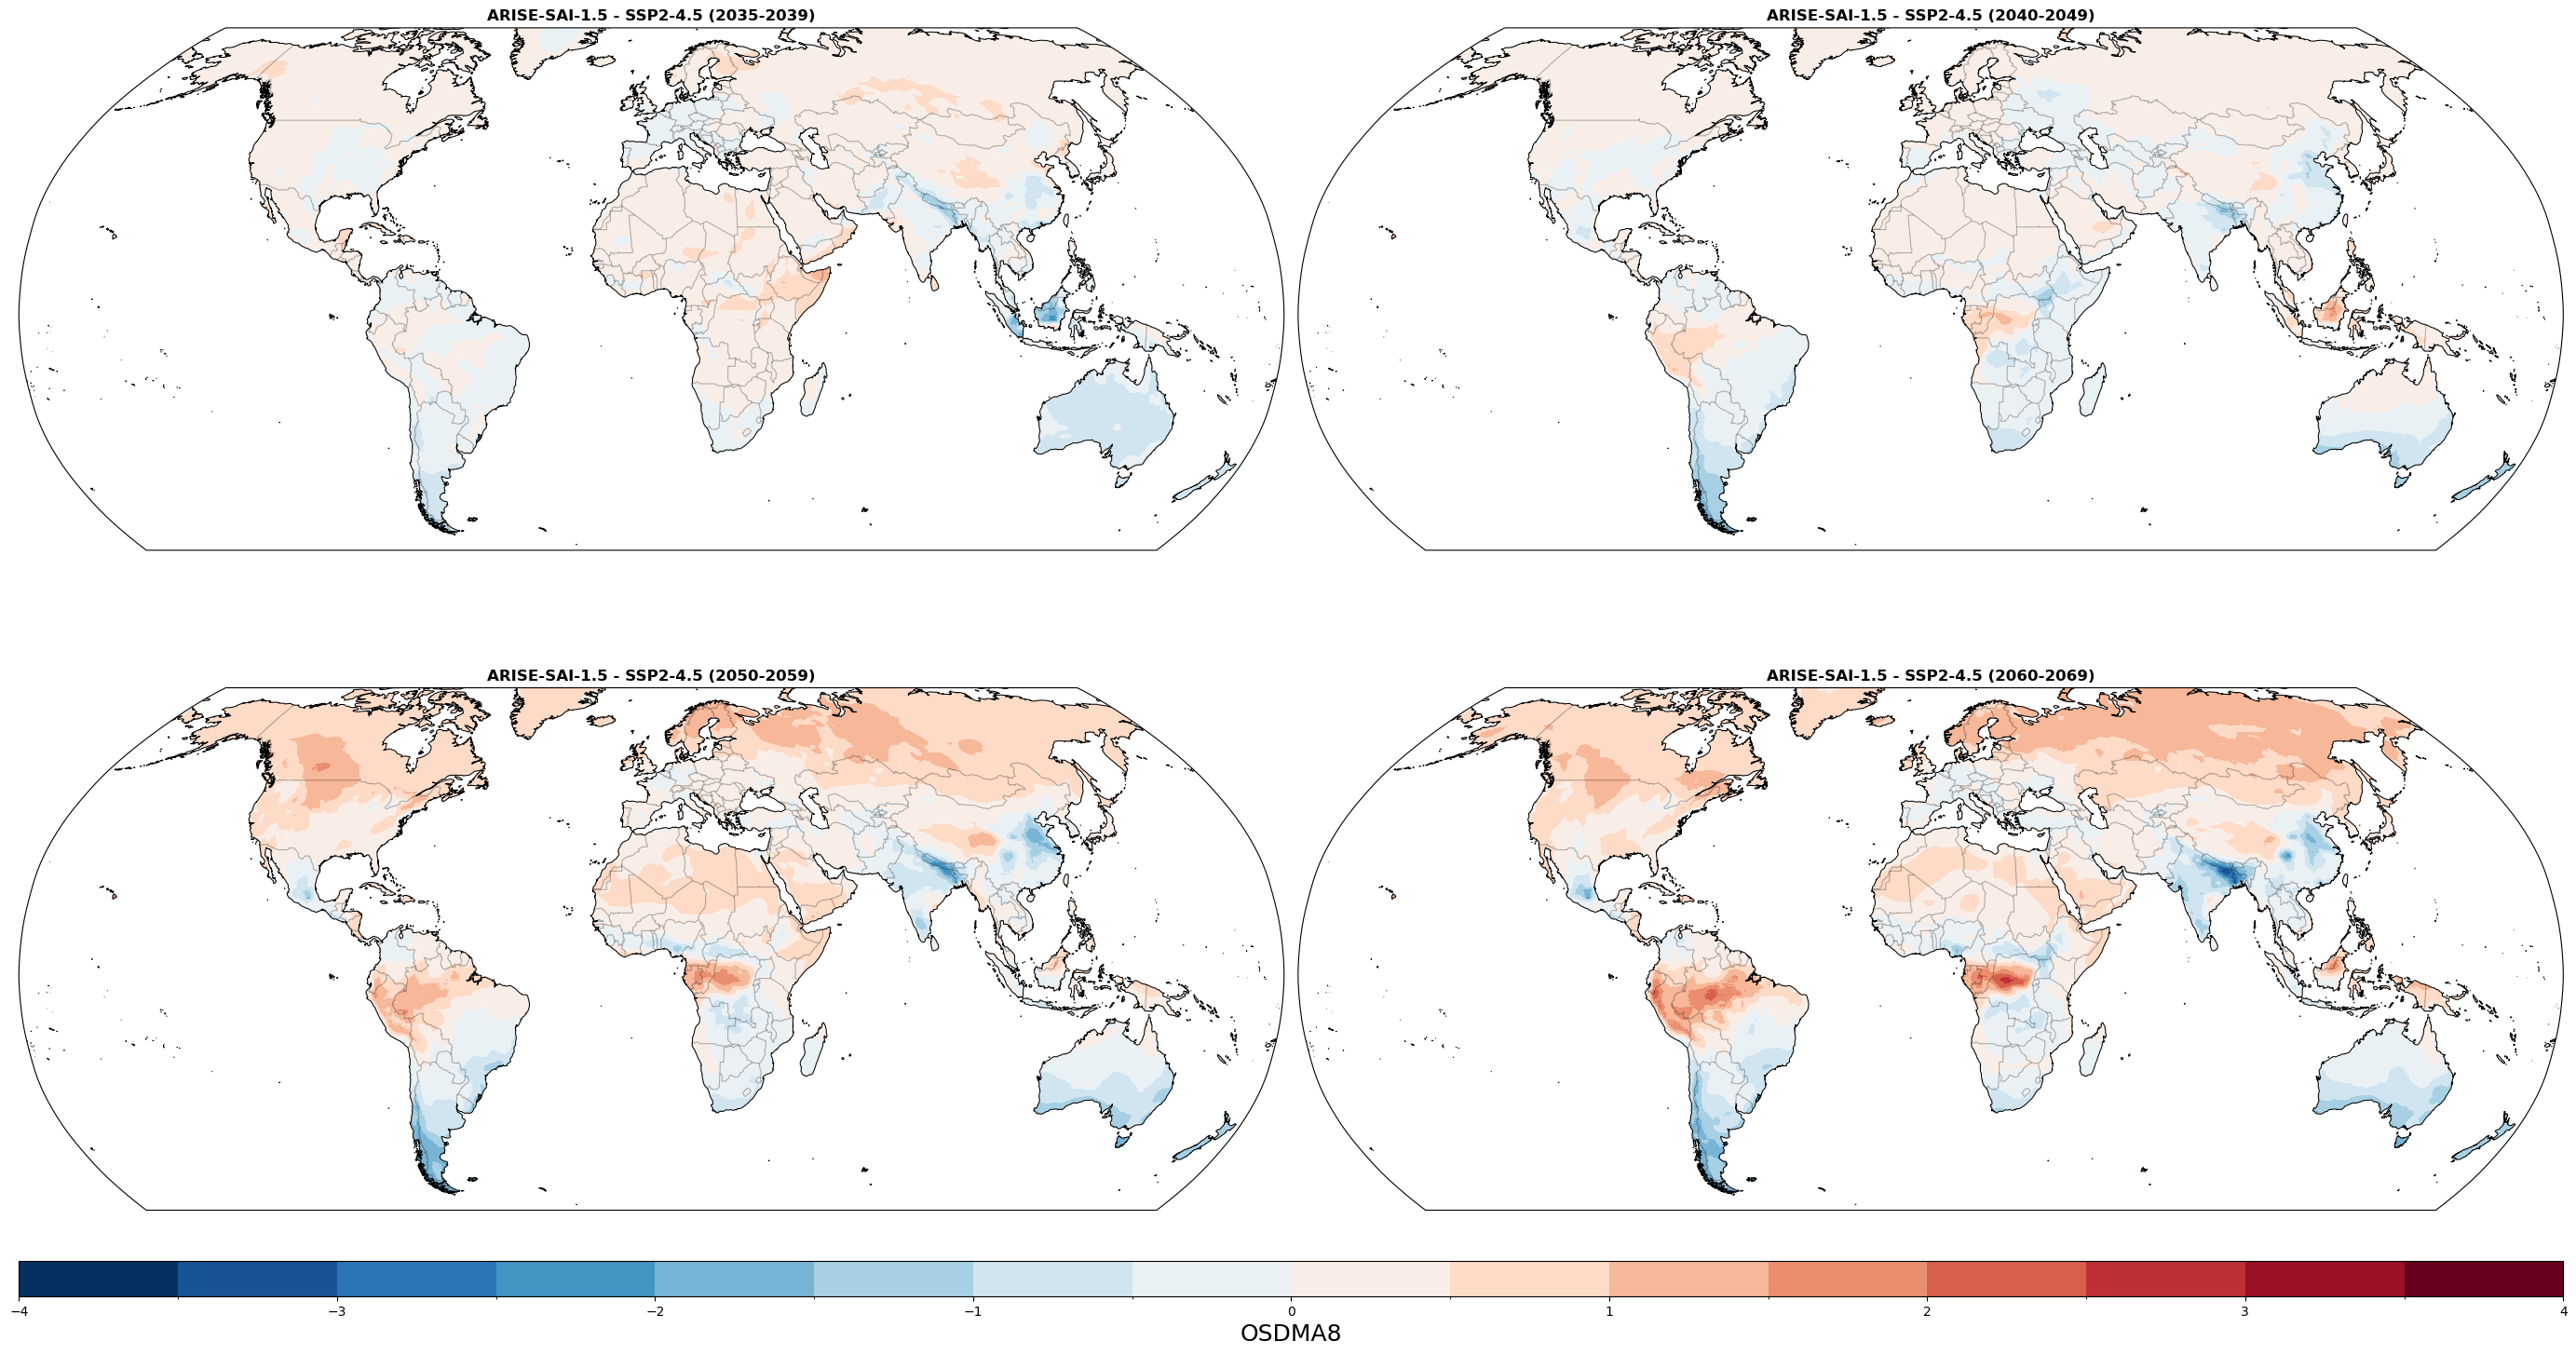

In [47]:
fig = plt.figure(figsize=autosize_figure(2, 2, scale_factor=1.6, xscale_factor=1.3))
gs = GridSpec(3, 2, height_ratios=[20, 20, 1]) # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

col_map = plt.get_cmap('Reds')

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')

levels = [-4, -3.5, -3, -2.5, -2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]

# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = land_filter(diff_30s).plot(transform=crs, add_colorbar=False, levels=levels,
                                subplot_kws={'projection': projection})
# pval_30s.where(pval_30s > 0.05).plot.contourf(transform=crs, colors='none', levels=[0, 1], hatches=['...'], add_colorbar=False)
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75, alpha=0.3)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2035-2039)", fontweight='bold')

# Second panel
ax = fig.add_subplot(gs[0, 1], projection=projection, frameon=True)
cb = land_filter(diff_40s).plot(transform=crs, add_colorbar=False, levels=levels,
                                subplot_kws={'projection': projection})
# pval_40s.where(pval_40s > 0.05).plot.contourf(transform=crs, colors='none', levels=[0, 1], hatches=['...'], add_colorbar=False)
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75, alpha=0.3)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2040-2049)", fontweight='bold')

# Third panel
ax = fig.add_subplot(gs[1, 0], projection=projection, frameon=True)
cb = land_filter(diff_50s).plot(transform=crs, add_colorbar=False, levels=levels,
                                subplot_kws={'projection': projection})
# pval_50s.where(pval_50s > 0.05).plot.contourf(transform=crs, colors='none',
#                                              levels=[0, 1], hatches=['...'],
#                                              add_colorbar=False)
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75, alpha=0.3)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2050-2059)", fontweight='bold')

# Fourth panel
ax = fig.add_subplot(gs[1, 1], projection=projection, frameon=True)
cb = land_filter(diff_60s).plot(transform=crs, add_colorbar=False, levels=levels,
                                subplot_kws={'projection': projection})
# pval_60s.where(pval_60s > 0.05).plot.contourf(transform=crs, colors='none',
#                                              levels=[0, 1], hatches=['...'],
#                                              add_colorbar=False)
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75, alpha=0.3)
plt.title("ARISE-SAI-1.5 - SSP2-4.5 (2060-2069)", fontweight='bold')

# Colorbar
cax = fig.add_subplot(gs[2, :])
col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
col_bar.set_label('OSDMA8', fontsize=18)

plt.tight_layout()